<a href="https://colab.research.google.com/github/ayaz-ali-36/Machine-Learning/blob/main/LogisticRegression/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split,
                                     cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_curve, auc,
                              accuracy_score)
from sklearn.dummy import DummyClassifier
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

In [7]:
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df  = pd.read_csv(url)


In [34]:
df.shape

(303, 14)

In [13]:

df.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [16]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [19]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [23]:
print("\n" + "="*50)
print("COLUMN DESCRIPTIONS")
print("="*50)
descriptions = {
    'age':      'Age in years',
    'sex':      '1=male, 0=female',
    'cp':       'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure',
    'chol':     'Serum cholesterol mg/dl',
    'fbs':      'Fasting blood sugar > 120mg (1=true)',
    'restecg':  'Resting ECG results (0-2)',
    'thalach':  'Maximum heart rate achieved',
    'exang':    'Exercise induced angina (1=yes)',
    'oldpeak':  'ST depression induced by exercise',
    'slope':    'Slope of peak exercise ST segment',
    'ca':       'Number of major vessels (0-3)',
    'thal':     'Thalassemia type',
    'target':   '1=Heart disease, 0=No disease'
}
for col, desc in descriptions.items():
    print(f"  {col:} → {desc}")


COLUMN DESCRIPTIONS
  age → Age in years
  sex → 1=male, 0=female
  cp → Chest pain type (0-3)
  trestbps → Resting blood pressure
  chol → Serum cholesterol mg/dl
  fbs → Fasting blood sugar > 120mg (1=true)
  restecg → Resting ECG results (0-2)
  thalach → Maximum heart rate achieved
  exang → Exercise induced angina (1=yes)
  oldpeak → ST depression induced by exercise
  slope → Slope of peak exercise ST segment
  ca → Number of major vessels (0-3)
  thal → Thalassemia type
  target → 1=Heart disease, 0=No disease


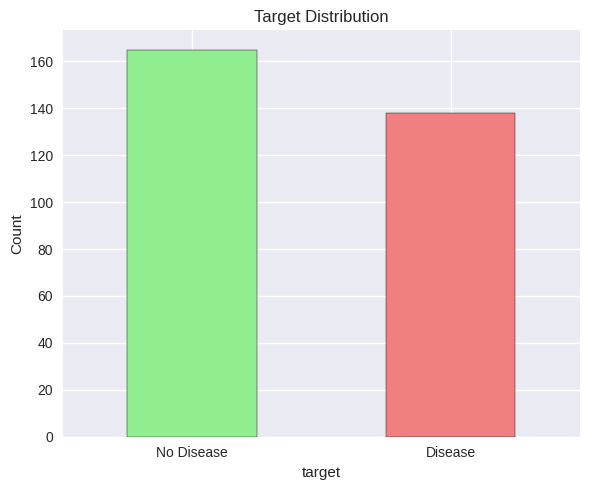

In [27]:
plt.figure(figsize=(6, 5))
df['target'].value_counts().plot(
    kind='bar',
    color=['lightgreen', 'lightcoral'],
    edgecolor='black'
)
plt.title('Target Distribution')
plt.xticks([0, 1],
           ['No Disease', 'Disease'],
           rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

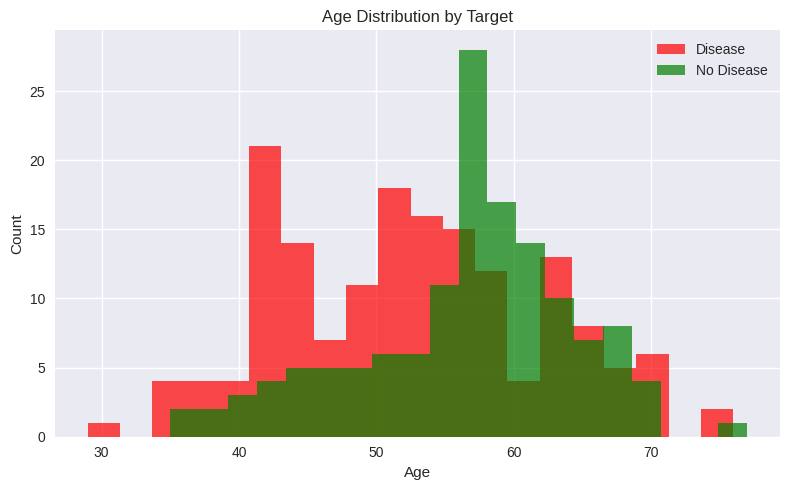

In [29]:
# Age distribution by target
plt.figure(figsize=(8, 5))
df[df['target']==1]['age'].hist(
    bins=20, alpha=0.7,
    label='Disease', color='red')
df[df['target']==0]['age'].hist(
    bins=20, alpha=0.7,
    label='No Disease', color='green')
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

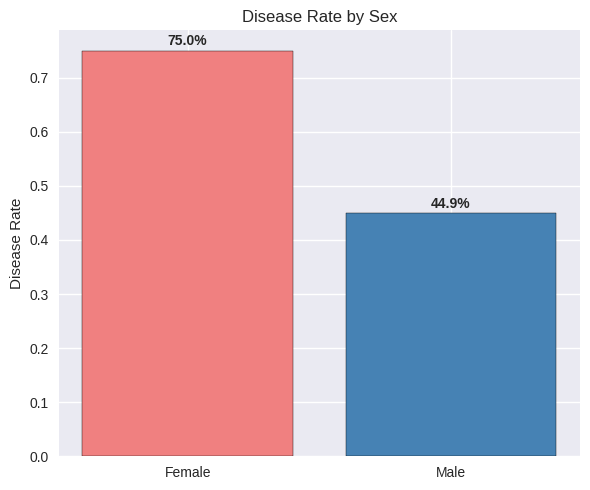

In [30]:
plt.figure(figsize=(6, 5))
sex_rate = df.groupby('sex')['target'].mean()
plt.bar(['Female', 'Male'],
        sex_rate.values,
        color=['lightcoral', 'steelblue'],
        edgecolor='black')
plt.title('Disease Rate by Sex')
plt.ylabel('Disease Rate')
for i, v in enumerate(sex_rate.values):
    plt.text(i, v + 0.01,
             f'{v:.1%}',
             ha='center',
             fontweight='bold')
plt.tight_layout()
plt.show()


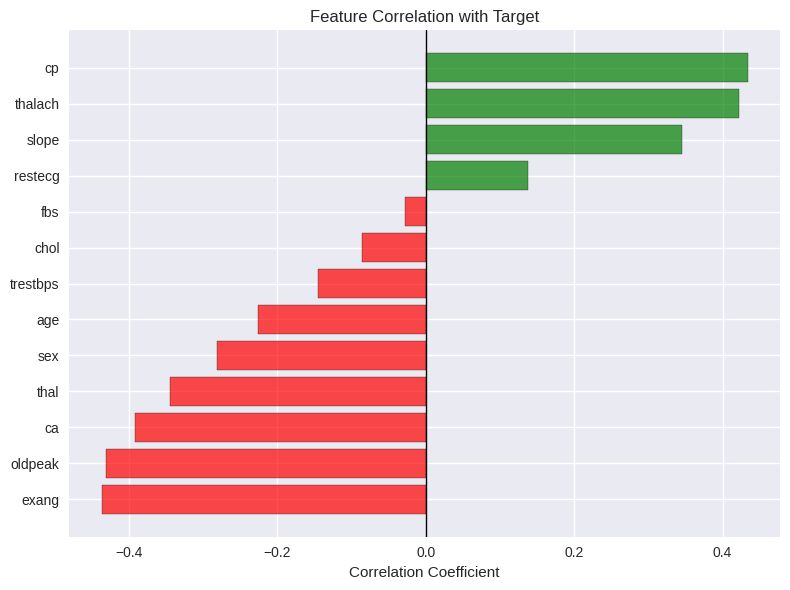

In [31]:
plt.figure(figsize=(8, 6))
corr = df.corr()['target'].drop('target')\
         .sort_values()
colors = ['red' if c < 0 else 'green'
          for c in corr.values]
plt.barh(corr.index, corr.values,
         color=colors, alpha=0.7,
         edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Correlation with Target')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [32]:
print("KEY EDA STATS")
print("="*40)
print(f"Avg age WITH disease:    "
      f"{df[df['target']==1]['age'].mean():.1f}")
print(f"Avg age WITHOUT disease: "
      f"{df[df['target']==0]['age'].mean():.1f}")
print(f"Avg cholesterol WITH:    "
      f"{df[df['target']==1]['chol'].mean():.1f}")
print(f"Avg cholesterol WITHOUT: "
      f"{df[df['target']==0]['chol'].mean():.1f}")

KEY EDA STATS
Avg age WITH disease:    52.5
Avg age WITHOUT disease: 56.6
Avg cholesterol WITH:    242.2
Avg cholesterol WITHOUT: 251.1


In [33]:
cat_cols = ['cp', 'restecg', 'slope', 'thal']
df_model = pd.get_dummies(df,
                           columns=cat_cols,
                           drop_first=True)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_model.shape}")
print(f"New columns: {df_model.shape[1] - df.shape[1]}"
      f" added by encoding")


Shape before encoding: (303, 14)
Shape after encoding:  (303, 20)
New columns: 6 added by encoding


In [35]:
X = df_model.drop('target', axis=1)
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 242
Test samples:     61
Features:         19


In [36]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_sc, y_train)
baseline_acc = baseline.score(X_test_sc, y_test)
print(f"Baseline accuracy: {baseline_acc:.3f}")
print("This model always predicts most frequent class")
print("Our model must beat this meaningfully")

Baseline accuracy: 0.541
This model always predicts most frequent class
Our model must beat this meaningfully


In [38]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    C=1.0
)
model.fit(X_train_sc, y_train)

# Cross validation
cv_scores = cross_val_score(
    model, X_train_sc, y_train,
    cv=5, scoring='f1'
)
print(f"5-Fold CV F1 Scores: {cv_scores.round(3)}")
print(f"Mean F1:  {cv_scores.mean():.3f}")
print(f"Std F1:   {cv_scores.std():.3f}")
print(f"(Low std = consistent model)")

5-Fold CV F1 Scores: [0.836 0.847 0.852 0.885 0.906]
Mean F1:  0.865
Std F1:   0.026
(Low std = consistent model)


In [40]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Model Accuracy:    "
      f"{accuracy_score(y_test, y_pred):.3f}")
print(f"\nFull Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No Disease', 'Disease']))

Baseline Accuracy: 0.541
Model Accuracy:    0.836

Full Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.75      0.81        28
     Disease       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



STEP 7: EVALUATION RESULTS
Baseline Accuracy: 0.541
Model Accuracy:    0.836

Full Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.75      0.81        28
     Disease       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



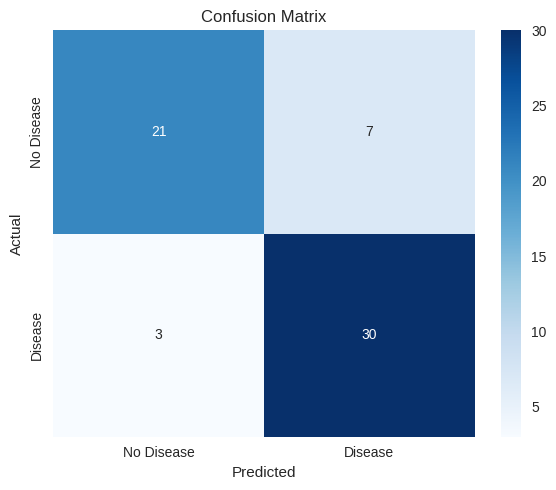

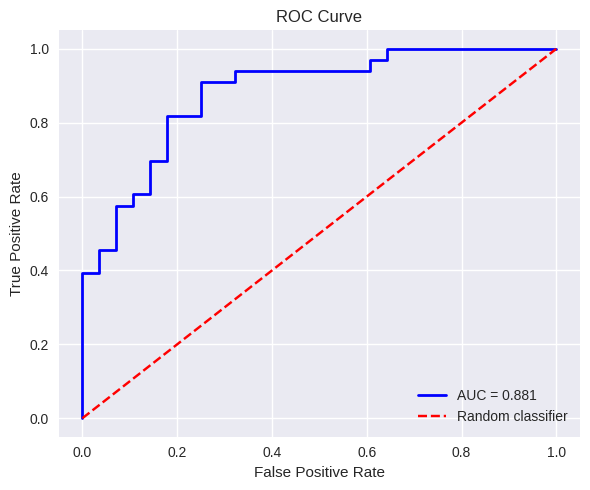

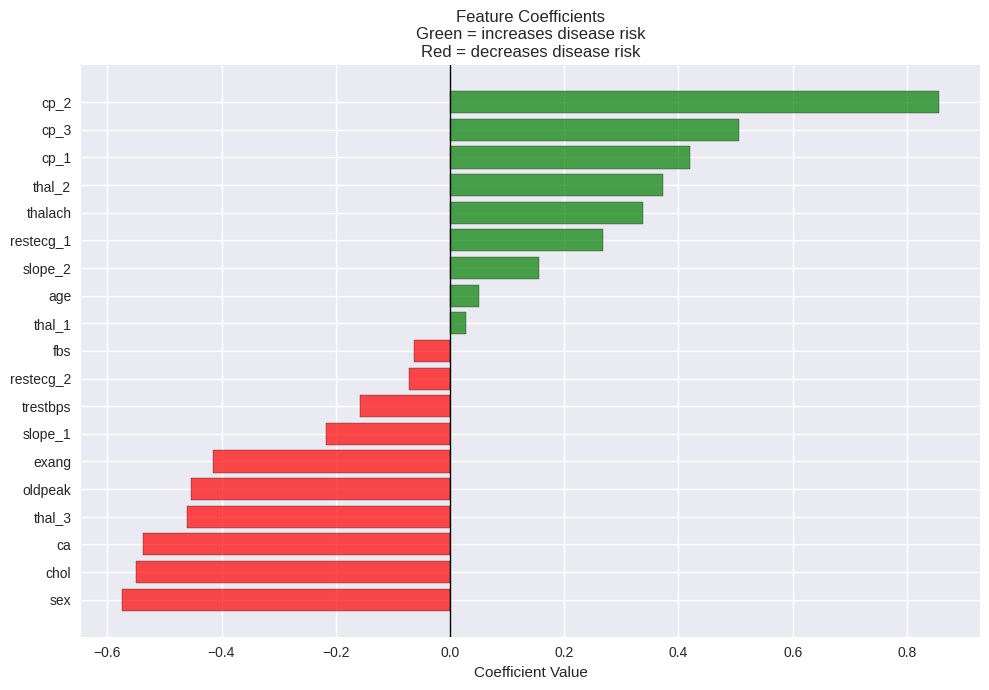


Top 5 features increasing risk:
    Feature  Coefficient
5   thalach     0.338209
17   thal_2     0.372550
9      cp_1     0.420571
11     cp_3     0.506350
10     cp_2     0.856363

Top 5 features decreasing risk:
    Feature  Coefficient
1       sex    -0.574316
3      chol    -0.549889
8        ca    -0.537194
18   thal_3    -0.460220
7   oldpeak    -0.453552


In [42]:
# ───────────────────────────────────────────────
# STEP 7: EVALUATE — CLEAN VERSION
# ───────────────────────────────────────────────
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print("="*50)
print("STEP 7: EVALUATION RESULTS")
print("="*50)
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Model Accuracy:    "
      f"{accuracy_score(y_test, y_pred):.3f}")
print(f"\nFull Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No Disease', 'Disease']))

# Plot 1: Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Plot 2: ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = auc(fpr, tpr)
plt.plot(fpr, tpr, 'b-', linewidth=2,
         label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], 'r--',
         label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# Plot 3: Feature Importance
plt.figure(figsize=(10, 7))
feat_imp = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

colors = ['red' if c < 0 else 'green'
          for c in feat_imp['Coefficient']]
plt.barh(feat_imp['Feature'],
         feat_imp['Coefficient'],
         color=colors,
         alpha=0.7,
         edgecolor='black')
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Feature Coefficients\n'
          'Green = increases disease risk\n'
          'Red = decreases disease risk')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print("\nTop 5 features increasing risk:")
print(feat_imp.tail(5)[['Feature',
                          'Coefficient']])
print("\nTop 5 features decreasing risk:")
print(feat_imp.head(5)[['Feature',
                          'Coefficient']])

In [43]:
from sklearn.metrics import (precision_score,
                              recall_score,
                              f1_score)
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_prob >= thresh).astype(int)
    p = precision_score(y_test, preds,
                        zero_division=0)
    r = recall_score(y_test, preds,
                     zero_division=0)
    f = f1_score(y_test, preds,
                 zero_division=0)
    marker = " ← default" if thresh == 0.5 else ""
    print(f"{thresh:<12.1f} {p:<12.3f}"
          f"{r:<12.3f} {f:<12.3f}{marker}")

0.3          0.738       0.939        0.827       
0.4          0.769       0.909        0.833       
0.5          0.811       0.909        0.857        ← default
0.6          0.839       0.788        0.812       
0.7          0.852       0.697        0.767       


In [44]:
sample      = X_test.head(5)
sample_prob = model.predict_proba(
    scaler.transform(sample))[:, 1]
sample_actual = y_test.head(5).values

for i, (prob, actual) in enumerate(
    zip(sample_prob, sample_actual)):
    pred    = "DISEASE" if prob >= 0.5 else "HEALTHY"
    reality = "DISEASE" if actual == 1 else "HEALTHY"
    correct = "✅" if pred == reality else "❌"
    print(f"Patient {i+1}: {prob:.1%} risk "
          f"→ Predicted: {pred} "
          f"| Actual: {reality} {correct}")


Patient 1: 3.8% risk → Predicted: HEALTHY | Actual: HEALTHY ✅
Patient 2: 10.8% risk → Predicted: HEALTHY | Actual: HEALTHY ✅
Patient 3: 0.7% risk → Predicted: HEALTHY | Actual: HEALTHY ✅
Patient 4: 82.9% risk → Predicted: DISEASE | Actual: HEALTHY ❌
Patient 5: 58.3% risk → Predicted: DISEASE | Actual: HEALTHY ❌
